<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/40_SVM_Own.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression,Ridge,SGDRegressor,Lasso,ElasticNet,LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error,accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve
from sklearn.preprocessing import StandardScaler,PolynomialFeatures,LabelEncoder
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_regression, load_diabetes, make_blobs
import  plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import load_diabetes,make_classification,load_iris,make_circles
import time
import matplotlib.animation as animation
from sklearn.svm import SVC

import random
from mlxtend.plotting import  plot_decision_regions
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


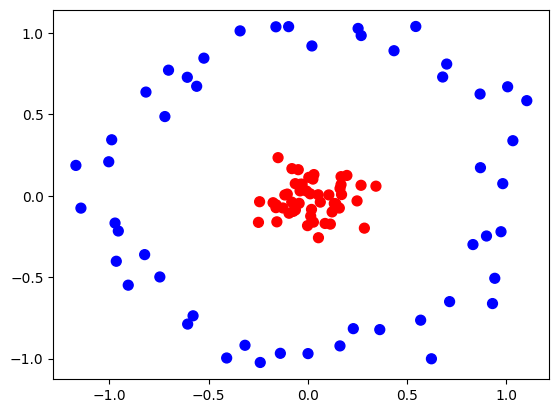

In [34]:
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')


In [76]:
df = pd.DataFrame({'f1': X[:,0], 'f2': X[:,1], 'y': y})
df

,f1,f2,y
0,0.982247,0.073852,0
1,-0.063657,0.073852,1
2,-0.044155,-0.046959,1
3,-0.048514,0.159568,1
4,0.000632,-0.969561,0
...,...,...,...
95,-0.062940,-0.087554,1
96,-0.955614,-0.216718,0
97,-0.317041,-0.918372,0
98,-0.081443,-0.039383,1


In [78]:
df = pd.DataFrame(X,columns=[["f1","f2"]])
df

,f1,f2
0,0.982247,0.073852
1,-0.063657,0.073852
2,-0.044155,-0.046959
3,-0.048514,0.159568
4,0.000632,-0.969561
...,...,...
95,-0.062940,-0.087554
96,-0.955614,-0.216718
97,-0.317041,-0.918372
98,-0.081443,-0.039383


In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [79]:
svm=SVC(kernel="rbf",probability=True)
svm.fit(X_train,y_train)
y_pred=svm.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [80]:
svm.predict_proba(X_test).argmax(axis=1)

array([1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1])

In [83]:
svm.classes_

array([0, 1])

<Axes: >

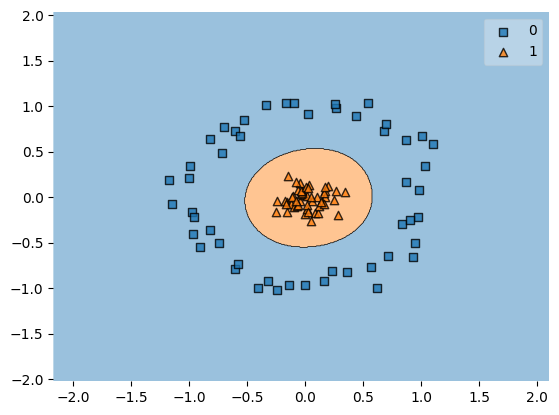

In [81]:
plot_decision_regions(X,y,svm,legend=True)

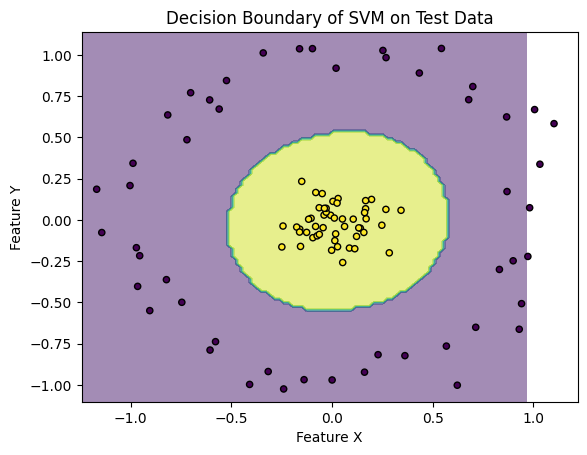

In [82]:
# Determine the range for the grid based on X_test
# Use the min/max of the first two features for the grid
x_min, x_max = X_test[:, 0].min() - 0.1, X_test[:, 0].max() + 0.1
y_min, y_max = X_test[:, 1].min() - 0.1, X_test[:, 1].max() + 0.1

# Create a meshgrid
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Flatten the meshgrid points for prediction
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict classes for all points in the meshgrid
Z = svm.predict(grid_points)

# Reshape the predictions back to the meshgrid shape
Z = Z.reshape(xx.shape)

# Plot the contourf and scatter original points
plt.contourf(xx, yy, Z, alpha=0.5)
# Correctly pass the first column of X_test for x and the second for y
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
plt.title('Decision Boundary of SVM on Test Data') # Changed title to SVM
plt.xlabel('Feature X')
plt.ylabel('Feature Y')
plt.show()

In [91]:
data=np.array([[0.982247,0.073852]])
index=svm.predict_proba(data).argmax(axis=1)
svm.classes_[index]

array([0])